# Phase 1: Agentic Research Pipeline

## Overview

Phase 1 runs a **closed-loop LLM research pipeline** that autonomously proposes, implements, backtests, and evaluates quantitative factor hypotheses for cross-sectional equity return prediction.  The goal is to systematically explore the factor space across multiple domains until enough factors have been tested for **BHY multiple-testing correction** to identify statistically robust signals.

---

## The 5-Step Agentic Loop

Each pipeline iteration executes five steps in sequence:

| Step | Agent / Component | What it does |
|------|------------------|-------------|
| **1. Synthesis** | Groq Llama 3.3-70B (primary) or Cerebras Qwen3 235B | Proposes a structured hypothesis: domain, mechanism, description, `mechanism_score` (1–5), and a `factor_name`. Reads the KB to avoid re-generating ideas already tested. |
| **2. Implementation** | Ollama Qwen2.5-Coder:14b (local) | Writes a Python `factor(prices)` function from the description. Only `pd`, `np`, `stats` are available — no file I/O, no network, no future data. |
| **3. Backtest** | `WalkForwardValidator` | OOS walk-forward backtest on 449 S&P 500 stocks (2018–2024). Computes IC, ICIR, net IC, Sharpe, turnover, and IC decay at 4 horizons. |
| **4. Analysis** | `AnalysisAgent` (LLM) | Interprets the metrics, writes a verdict (PASS / WEAK / FAIL), flags anomalies (look-ahead, NaN, constant signal). |
| **5. KB write** | `KnowledgeBase` (SQLite) | Logs hypothesis, code, and all metrics. Nothing is lost between sessions. |

**Every 5 iterations** the loop also runs automatically:
- **Correlation analysis** — pairwise Spearman correlations between all positive-IC signals (stored in `factor_correlations` table)
- **Ensemble check** — IC-weighted blend of the top 3 most uncorrelated factors, backtested and logged as `ensemble_top3`

---

## Gate 1 — BHY Multiple Testing Correction

Running 100+ factors on the same dataset means roughly 5 will appear significant by chance at p < 0.05.  Phase 1 applies **BHY (Benjamini-Hochberg-Yekutieli)** correction to control the False Discovery Rate (FDR):

- With ~100 factors tested, BHY requires approximately **t ≥ 4.0** (α = 0.05 FDR) for a factor to be considered genuinely significant.
- Factors meeting this threshold are **BHY-significant** and advance to Phase 2 regime analysis.
- **Slow-signal caveat:** for factors with IC peaking at h ≥ 21 days, use the non-overlapping window t-statistic: `slow_icir_63 × √(N / 63)` — not the standard formula, which overcounts observations by up to √63 ≈ 8×.

---

## Notebook Structure

| Section | Purpose | Safe to run? |
|---------|---------|--------------|
| **A** | Browse results — KB tables, leaderboard, IC decay, code viewer | ✅ Anytime — read-only |
| **A2** | Advanced visualisations — 15 charts from the viz module | ✅ Anytime — read-only |

Start with **Section A** to review what CLI runs have already produced.

In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.join(repo_root, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(repo_root, 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

KB_PATH = os.path.join(repo_root, 'knowledge_base', 'qframe.db')

# ── Configurable parameters ────────────────────────────────────────────────
N_OOS_DAYS = 1762          # OOS trading days (2018-01-01 → 2024-12-31)
HORIZON    = 1             # Default forward-return horizon (days).
                           # Change to 5, 21, or 63 for slow-signal evaluation.
                           # Used by Chart 14 (temporal stability) and t-stat formula.

print('Ready. KB:', KB_PATH)
print(f'N_OOS_DAYS={N_OOS_DAYS}  HORIZON={HORIZON}')

Ready. KB: /Users/franciscosimao/Documents/quant-learning/projects/qframe/knowledge_base/qframe.db
N_OOS_DAYS=1762  HORIZON=1


---
**Naming convention:** first mention of any factor uses both ID and name — `impl_82 (trend_quality_calmar_ratio)`. All subsequent mentions: `impl_82`. Tables must include both `impl_id` and `factor_name` columns.

**Assumptions:** universe = S&P 500 449 stocks (survivorship-biased), date range 2010-01-04 → 2024-12-30, OOS start 2018-01-01, rebalance daily (h=1), cost model `DEFAULT_COST_PARAMS` (10 bps spread, γ=30), multiple-testing correction = BHY (α=0.05).

In [2]:
# Factor identity card — change impl_id to inspect any factor
from qframe.viz.identity import print_factor
# print_factor(82)   # uncomment to inspect impl_82 (trend_quality_calmar_ratio)

---
## Section A — Browse Existing Results

These cells query the knowledge base directly and display results. Nothing new is generated or run.

The KB at this stage contains all factors produced by the CLI pipeline (`./run_pipeline.sh`), including:
- Every hypothesis the synthesis agent proposed
- The implementation code the model wrote
- All backtest metrics (IC, ICIR, net IC, Sharpe, turnover, decay)
- Pass/fail gate verdicts from the analysis agent

Run these cells after any CLI batch to inspect what was discovered.

#### Hypotheses table

A **hypothesis** is a structured proposal from the Synthesis agent:
> *"This observable pattern in price/fundamental data should predict future cross-sectional returns
because of [economic mechanism]."*

Each hypothesis has a short name (`factor_name`), a description, and a `mechanism_score` (1–5):

| Score | Meaning |
|-------|---------|
| 1 | Pure data-mining — no theoretical justification |
| 2 | Stylised fact — empirically observed but mechanism unclear |
| 3 | Plausible mechanism — reasonable causal story |
| 4 | Strong theory — backed by established literature (e.g., Fama-French, JT1993) |
| 5 | Causal evidence — natural experiment or structural model support |

Higher mechanism scores reduce the multiple-testing penalty: we should require less statistical
evidence for a signal that has clear theoretical support.

**Status values:**
- `backlog` — proposed, not yet backtested
- `active` — currently being backtested
- `passed` / `weak` — backtest complete, IC ≥ 0.03 / ≥ 0.02
- `failed` — backtest complete, IC < 0.02


In [3]:
# --- All hypotheses ---
from qframe.knowledge_base.db import KnowledgeBase
import sqlite3

kb = KnowledgeBase(KB_PATH)

conn = sqlite3.connect(KB_PATH)
hypotheses = pd.read_sql("""
    SELECT h.id, h.description, h.mechanism_score, h.status,
           i.id AS impl_id
    FROM hypotheses h
    LEFT JOIN implementations i ON i.hypothesis_id = h.id
    ORDER BY h.id
""", conn)
conn.close()

print(f'{len(hypotheses)} hypotheses in KB')
hypotheses

129 hypotheses in KB


,id,description,mechanism_score,status,impl_id
0,1,"Return from 12 to 7 months ago, measured as pr...",5,failed,1
1,2,Cross-sectional momentum signal adjusted for i...,4,failed,2
2,3,Momentum signal based on residual returns afte...,4,failed,3
3,4,"Ratio of current price to 52-week high, measur...",4,failed,4
4,5,"One-month return with a negative sign, capturi...",4,failed,5
...,...,...,...,...,...
124,125,Ratio of long-term realized semivariance to sh...,4,failed,125
125,126,Ratio of 126-day realized volatility to 21-day...,4,failed,126
126,127,Idiosyncratic volatility measured as the stand...,4,failed,127
127,128,IC-weighted ensemble of top 1 factors: industr...,4,failed,128


#### Backtest results table — metric definitions

Each row is one completed backtest over the OOS period (2018-01-01 to 2024-12-31).

| Column | Definition | What to look for |
|--------|-----------|------------------|
| `ic` | Spearman rank correlation(factor score, next-day return) — primary quality metric | ≥ 0.03 = PASS; ≥ 0.02 = WEAK; < 0.02 = FAIL |
| `icir` | IC / rolling std(IC) — signal-to-noise ratio; measures IC consistency | > 0.5 is healthy; > 1.0 is strong |
| `net_ic` | IC after subtracting bid-ask spread, market impact, borrow drag | Must be positive for the strategy to be profitable net of costs |
| `sharpe` | Annualised IC Sharpe = ICIR × √252 | > 0.5 is target Gate 3 threshold |
| `turnover` | One-way daily fraction traded (0.10 = 10% of book replaced per day) | Lower is cheaper; high-IC/high-turnover factors often have poor net IC |
| `decay_halflife` | Days until IC halves from its h=1 value | Higher = more persistent signal; slow signals (h>21d) need high gross IC to overcome cost drag at long hold periods |
| `slow_icir_21/63` | ICIR computed on non-overlapping 21/63-day windows | More honest for slow factors; avoids autocorrelation inflation |

**Relationship between metrics:**  `net_ic ≈ gross_ic − cost_drag × turnover × horizon`.
A factor can have IC=0.05 but net_ic=−0.01 if it turns over 80% of the book daily.


In [4]:
# --- All backtest results (individual factors only — ensembles excluded) ---
import numpy as np

conn = sqlite3.connect(KB_PATH)
results = pd.read_sql("""
    SELECT
        h.factor_name,
        h.description,
        r.ic, r.icir, r.net_ic, r.sharpe,
        r.slow_icir_63,
        r.turnover, r.decay_halflife,
        r.ic_horizon_1, r.ic_horizon_5, r.ic_horizon_21, r.ic_horizon_63,
        r.passed_gate, r.notes,
        r.created_at
    FROM backtest_results r
    JOIN implementations i ON i.id = r.implementation_id
    JOIN hypotheses h ON h.id = i.hypothesis_id
    WHERE (
        h.factor_name IS NULL
        OR (
            h.factor_name NOT LIKE 'phase25_%'
            AND h.factor_name NOT LIKE 'ensemble_%'
            AND h.factor_name NOT LIKE 'combined_%'
        )
    )
""", conn)
conn.close()

# ── Compute t-stat and sort by it ─────────────────────────────────────────
# Fast signals: t = icir × √(N_OOS_DAYS / 252)
# Slow signals (|IC@63| > |IC@1|, same sign, slow_icir_63 available):
#              t = slow_icir_63 × √(N_OOS_DAYS / 63)
def _compute_tstat(row):
    h1        = float(row['ic_horizon_1']  or 0.0)
    h63       = float(row['ic_horizon_63'] or 0.0)
    slow_icir = float(row['slow_icir_63']  or 0.0)
    is_slow   = (abs(h63) > abs(h1)) and (h63 * h1 >= 0) and (slow_icir != 0)
    if is_slow:
        return slow_icir * np.sqrt(N_OOS_DAYS / 63)
    return float(row['icir'] or 0.0) * np.sqrt(N_OOS_DAYS / 252)

results['t_stat'] = results.apply(_compute_tstat, axis=1)
results = results.sort_values('t_stat', ascending=False).reset_index(drop=True)

print(f'{len(results)} backtest results (sorted by t-stat, N_OOS={N_OOS_DAYS}, horizon={HORIZON}d)')
results[['factor_name','description','ic','icir','t_stat','net_ic','sharpe','turnover','decay_halflife','passed_gate']]

17 backtest results (sorted by t-stat, N_OOS=1762, horizon=1d)


,factor_name,description,ic,icir,t_stat,net_ic,sharpe,turnover,decay_halflife,passed_gate
0,rsi_contrarian,Contrarian signal based on 14-day Relative Str...,0.003290,0.026708,3.129716,0.002852,0.265088,0.170915,NaN,0
1,short_term_reversal_jegadeesh,"One-month return with a negative sign, capturi...",0.001813,-0.079467,2.894285,0.001462,0.136944,0.136280,NaN,0
2,value_realized_volatility_ratio,Ratio of long-term realized volatility to shor...,0.003423,0.053735,1.963902,0.003185,0.406761,0.090964,NaN,0
3,trend_stability_ratio,Ratio of 252-day rolling realized volatility t...,0.004842,0.063944,0.586100,0.004715,0.568398,0.046406,NaN,0
4,idiosyncratic_volatility_residual_std,Idiosyncratic volatility measured as the stand...,0.000111,0.035367,0.303741,-0.000064,0.011400,0.065682,NaN,0
5,intermediate_momentum_novy_marx,"Return from 12 to 7 months ago, measured as pr...",0.009378,0.032143,0.084994,0.009229,0.731386,0.055706,3.668422,0
6,volatility_regime_duration,Number of consecutive trading days that long-t...,0.001377,0.017422,0.046068,0.001185,0.212363,0.072214,273.480947,0
7,bollinger_band_width_mean_reversion,Rolling 20-day Bollinger Band width as a measu...,0.001916,-0.000428,-0.001132,0.001721,0.152039,0.073948,NaN,0
8,industry_momentum_moskowitz_grinblatt,Cross-sectional momentum signal adjusted for i...,0.012461,-0.043885,-0.116043,0.012352,0.802096,0.039549,6.018235,0
9,trend_convexity_curvature,Rolling measure of trend curvature using secon...,-0.011041,-0.078009,-0.206277,-0.012712,-0.947529,0.662636,NaN,0


#### IC leaderboard

**Why IC is the primary metric:** The Information Coefficient measures how well the factor
*ranks* stocks relative to how they actually perform.  A factor with IC=0.05 over 1,762 OOS
days is saying: "on average, the stocks I ranked highest returned 5 percentage points more than
what a naïve rank would predict — consistently, across the entire OOS window."

**Gate thresholds (Phase 1):**
- 0.03 (solid horizontal line) = **PASS** — sufficient signal for Phase 2 evaluation
- 0.02 (dashed line) = **WEAK** — borderline; enters Phase 2 only if BHY-significant
- < 0.02 = **FAIL** — below noise floor; excluded from further analysis

**Sharpe alongside IC:**  IC measures average signal strength; Sharpe (IC / std(IC) × √252)
measures signal *consistency*.  A factor with IC=0.04 and Sharpe=1.5 is more valuable than
IC=0.06 and Sharpe=0.3 — the first is reliable every year, the second is dominated by
one exceptional year.


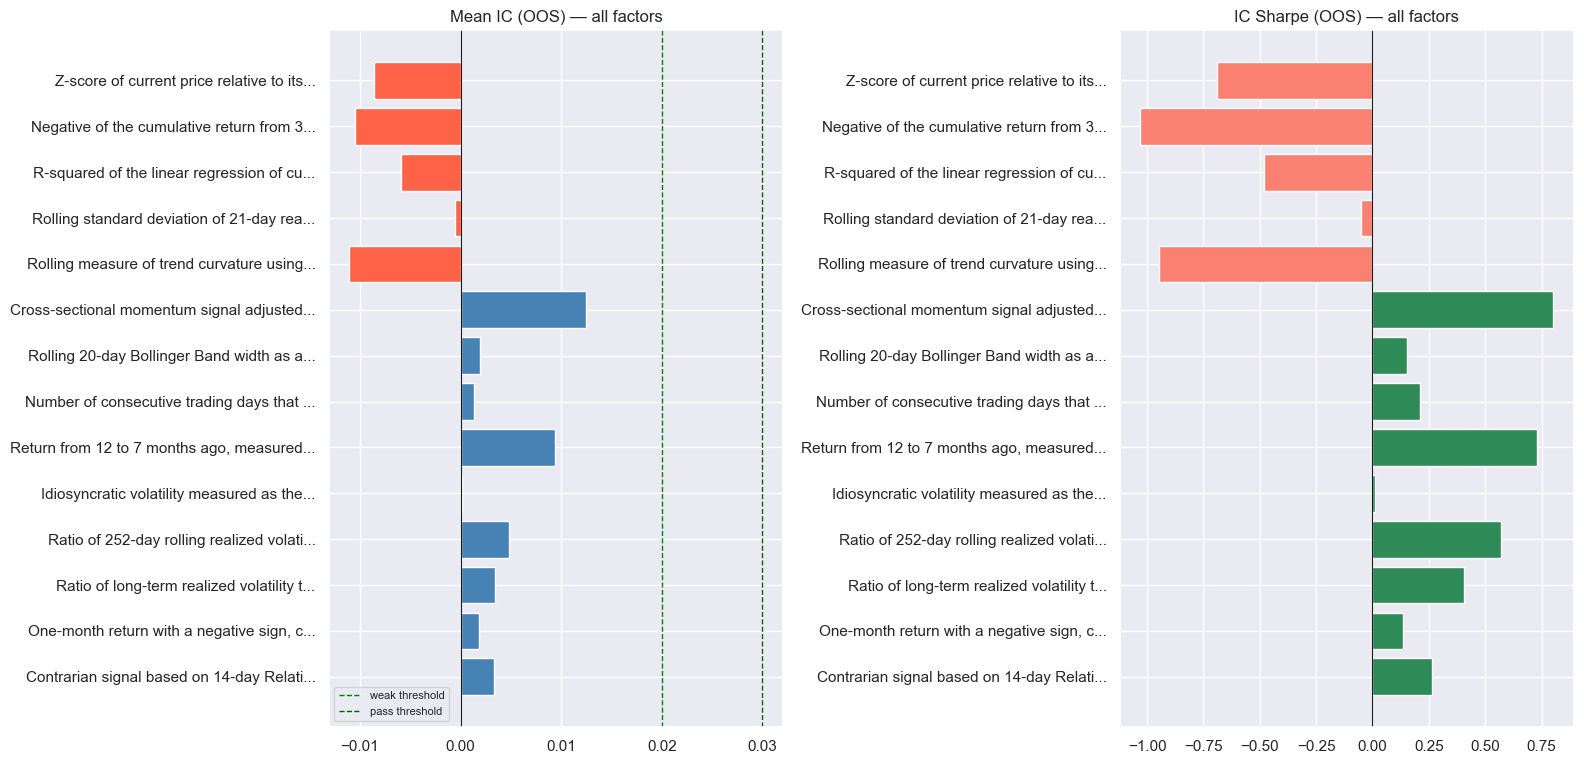

In [5]:
# --- IC leaderboard plot ---
if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(results) * 0.4 + 1)))

    labels = [d[:40] + '...' if len(d) > 40 else d for d in results['description']]

    # IC bar chart
    colors = ['steelblue' if v >= 0 else 'tomato' for v in results['ic']]
    axes[0].barh(labels, results['ic'], color=colors)
    axes[0].axvline(0, color='k', lw=0.8)
    axes[0].axvline(0.02, color='green', lw=1, ls='--', label='weak threshold')
    axes[0].axvline(0.03, color='darkgreen', lw=1, ls='--', label='pass threshold')
    axes[0].set_title('Mean IC (OOS) — all factors')
    axes[0].legend(fontsize=8)

    # Sharpe bar chart
    colors2 = ['seagreen' if v >= 0 else 'salmon' for v in results['sharpe']]
    axes[1].barh(labels, results['sharpe'], color=colors2)
    axes[1].axvline(0, color='k', lw=0.8)
    axes[1].set_title('IC Sharpe (OOS) — all factors')

    plt.tight_layout()
    plt.show()

#### IC decay heatmap

**What is IC decay?**  IC is computed at multiple horizons (1, 5, 21, 63 days).  As the horizon
grows, the factor's predictive power typically decays — information about today's cross-section
becomes less relevant for returns 3 months from now.

**Reading the heatmap:**
- Each row is a factor; each column is a horizon (1d → 63d)
- Colour intensity = IC magnitude (dark = stronger signal)
- **Factors peaking at h=1d:** fast signals (momentum micro-structure, overnight returns) —
  need low turnover costs to survive cost netting
- **Factors peaking at h=21-63d:** slow signals (quality metrics, value) — can be held longer,
  reducing turnover drag, but need higher gross IC to compensate for waiting

**Orange outline:**  Marks factors where `|IC@63d| > |IC@1d|` with the same sign — these are
**slow mean-reversion signals** that benefit from a long hold period.  Regime conditioning
(Phase 2) is especially valuable here because the HSMM 5-state model can detect whether the
market is in a trending vs mean-reverting regime before deciding how much exposure to take.


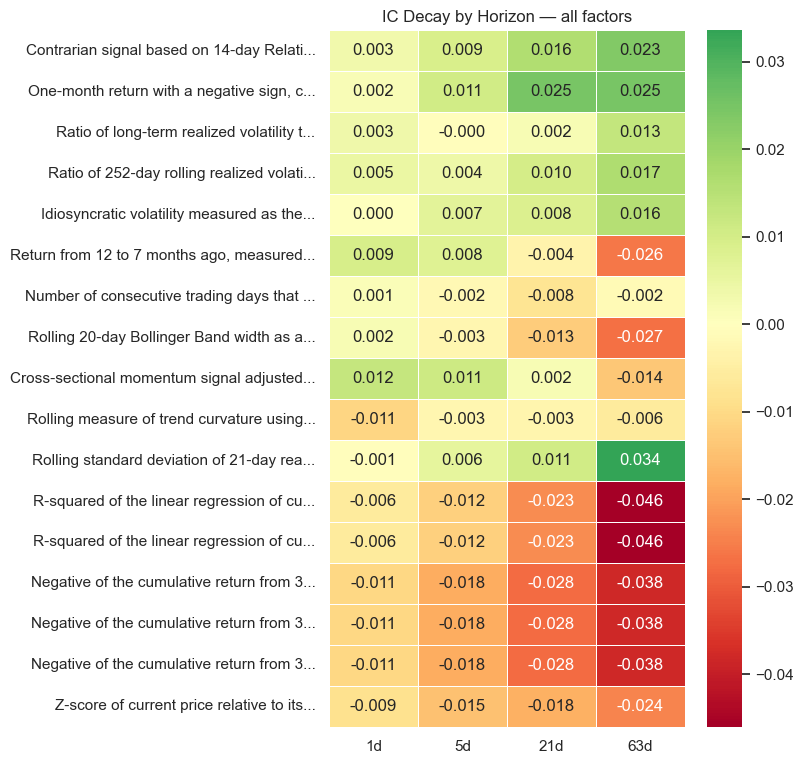

In [6]:
# --- IC decay heatmap ---
if len(results) > 0:
    decay_cols = ['ic_horizon_1','ic_horizon_5','ic_horizon_21','ic_horizon_63']
    decay_data = results[decay_cols].copy()
    decay_data.index = labels
    decay_data.columns = ['1d','5d','21d','63d']

    fig, ax = plt.subplots(figsize=(8, max(3, len(results) * 0.4 + 1)))
    sns.heatmap(decay_data, annot=True, fmt='.3f', center=0,
                cmap='RdYlGn', ax=ax, linewidths=0.5)
    ax.set_title('IC Decay by Horizon — all factors')
    plt.tight_layout()
    plt.show()

#### Factor code viewer

Each row in the knowledge base stores the exact Python function the LLM wrote.
Change `impl_id` in the cell below to inspect any specific implementation.

**What to look for in generated code:**
- **Rolling lookback** — does the factor use a window that is clearly in-sample only?
  e.g., `rolling(window=252)` uses the past 252 days only — correct.
  `expanding()` or `mean()` over the full price history — look-ahead bias risk.
- **Cross-sectional normalisation** — does the factor standardise rankings *within* a date?
  Factor weights should sum to zero across stocks (dollar-neutral) before returns are applied.
- **No direct use of future returns** — `shift(-1)` applied to returns would be look-ahead.
  The harness applies the 1-day shift automatically; the factor function should only compute
  scores from `prices` without shifting forward.

**Available in factor sandbox:** only `pd` (pandas), `np` (numpy), `stats` (scipy.stats).
No network calls, no file I/O, no external data — ensures reproducibility.


In [7]:
# --- View generated code for a specific factor ---
# Change impl_id to inspect any factor
INSPECT_IMPL_ID = 11

conn = sqlite3.connect(KB_PATH)
row = conn.execute(
    'SELECT h.description, i.code FROM implementations i '
    'JOIN hypotheses h ON h.id = i.hypothesis_id WHERE i.id = ?',
    (INSPECT_IMPL_ID,)
).fetchone()
conn.close()

if row:
    print(f'Factor: {row[0]}\n')
    print(row[1])
else:
    print(f'No implementation found for id={INSPECT_IMPL_ID}')

Factor: A proxy for Williams %R using only closing prices by measuring the relative position of the current price within the rolling N-day closing range.

def factor(prices: pd.DataFrame) -> pd.DataFrame:
    window = 14
    rolling_max = prices.rolling(window, min_periods=1).max()
    rolling_min = prices.rolling(window, min_periods=1).min()
    range_ = rolling_max - rolling_min
    relative_position = (prices - rolling_min) / range_.replace(0, np.nan)
    williams_r = -100 * relative_position
    return williams_r


---
## Section A2 — Advanced Visualisations (Charts 1–15)

All 15 charts read from the knowledge base only — safe to run at any time without triggering a new pipeline iteration.

Run the import cell once per session, then execute any chart cell independently.

### Chart overview by category

| Charts | Category | What they answer |
|--------|----------|-----------------|
| 1–3 | **Signal strength** | Which factors have the highest IC? Where does IC decay with horizon? |
| 4–6 | **Signal quality** | Is IC consistent (high ICIR)? Fast or slow signal? Is the edge accumulating? |
| 7–8 | **Cost efficiency** | Does the signal survive transaction costs? Is turnover proportionate to alpha? |
| 9 | **Diversification** | Are the positive-IC factors correlated with each other? |
| 10–12 | **Pipeline health** | Is the synthesis agent learning? Which domains are fertile? Is the error rate falling? |
| 13 | **Cost drag** | How much IC is lost to bid-ask spread and market impact, per factor? |
| 14 | **Temporal stability** | Was the factor consistently predictive across all calendar years, or concentrated in one era? |
| 15 | **Statistical significance** | Which factors survive BHY / HLZ / Bonferroni multiple-testing correction? |

In [8]:
# Import the viz module (run once per session)
from qframe.viz.charts import (
    plot_leaderboard, plot_ic_decay_curves, plot_ic_decay_heatmap,
    plot_ic_vs_icir, plot_ic1_vs_ic63, plot_cumulative_ic,
    plot_slow_icir_comparison, plot_turnover_scatter,
    plot_correlation_heatmap, plot_sharpe_histogram,
    plot_domain_breakdown, plot_error_rate, plot_net_vs_gross_ic,
    plot_ic_by_period, plot_multiple_testing,
)
print('viz module loaded')

viz module loaded


### Chart 1 — Factor Leaderboard (IC + Sharpe)

**Theory:** The leaderboard is the highest-level summary of Phase 1 results — the first thing to read after a batch run.

**Left panel — IC (Information Coefficient):** Mean Spearman rank correlation between factor scores and next-day returns over the full OOS period (2018–2024, ~1,762 days).  IC integrates over all market conditions — bull, bear, and sideways — and is the single most important metric for judging a factor's raw predictive power.

**Right panel — IC Sharpe:** Annualised IC Sharpe ratio (= ICIR × √252).  This measures whether the factor's predictive power was *consistent* or *sporadic*.  A factor with IC=0.04 but Sharpe=0.3 only worked in one exceptional year; a factor with IC=0.04 and Sharpe=2.0 worked reliably every year.

**Gate thresholds:**
- IC ≥ 0.03 (solid line) = **PASS** — sufficient signal for Phase 2 evaluation
- IC ≥ 0.02 (dashed line) = **WEAK** — borderline; enters Phase 2 only if BHY-significant
- IC < 0.02 = **FAIL** — below the noise floor

**Deduplication:** each factor appears once — the best result per `factor_name` is shown.  If the same signal was discovered in multiple runs (e.g., impl_82 and impl_92, both Calmar variants), only the higher IC entry is displayed.

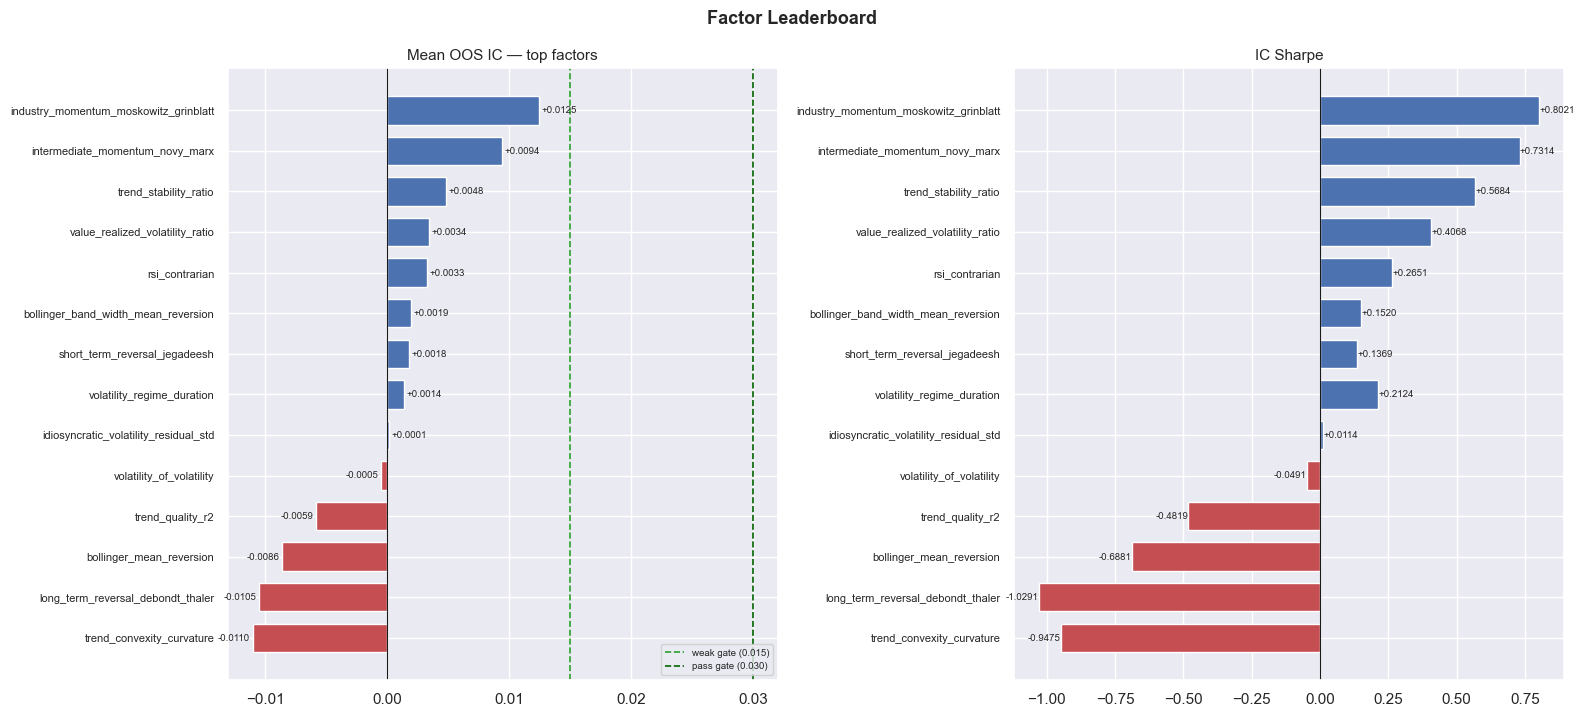

In [9]:
fig = plot_leaderboard(KB_PATH, top_n=28)
plt.show()

### Chart 2 — IC Decay Curves (individual lines per factor)

**Theory:** Each line plots mean IC at four forward-return horizons: 1d, 5d, 21d, 63d.  The decay shape reveals the *temporal structure* of the factor's edge and directly determines the optimal holding period and rebalancing frequency.

**Line styles:**
- **Dashed lines** — standard-decay factors: IC peaks at h=1 and decreases monotonically.  These are fast signals (momentum, short-term reversal, microstructure) that need daily or weekly rebalancing.  They incur the highest turnover costs.
- **Solid lines** — slow-decay or rising factors: IC *increases* from h=1 to h=63.  These are mean-reversion, quality, or value signals that benefit from longer holding periods and incur far less turnover drag.

**What to look for:**
- Does the best factor's IC remain positive at all four horizons? That indicates a robust signal that works at multiple time scales.
- Are there lines that cross from positive (h=1) to negative (h=63)? This is a *reversal* factor — it works short-term but bets against itself over the medium term.  Naïve blending with a slow signal would cancel the edge.
- The steepest-declining curves require the most frequent rebalancing and are most sensitive to transaction cost assumptions.

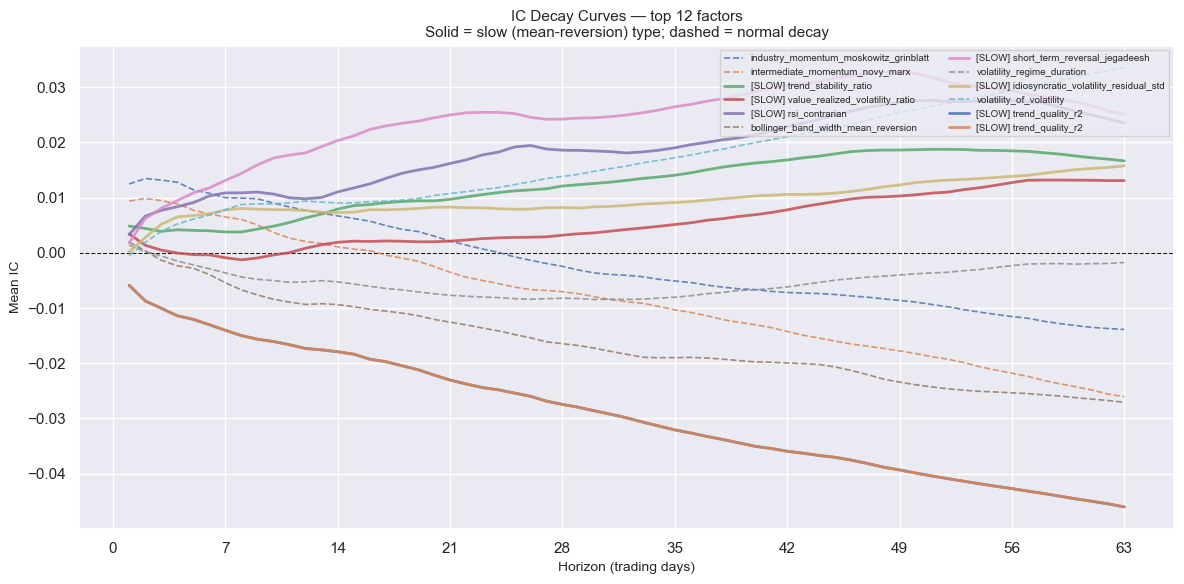

In [10]:
fig = plot_ic_decay_curves(KB_PATH, top_n=12)
plt.show()

### Chart 3 — IC Decay Heatmap (enhanced)

**Theory:** The same IC-by-horizon data as Chart 2, displayed as a grid for direct cross-factor comparison.  Each row is a factor; each column is a horizon; colour encodes IC magnitude (green = positive, red = negative).

**Orange outline:** marks cells where `|IC@63d| > |IC@1d|` with the same sign — these are **slow-accumulating signals** where a 63-day hold is more informative than a 1-day hold.  These factors are the most promising candidates for value/quality investing with patient, low-turnover strategies.

**Practical use:**
- Scan the 63d column for large positive values that do not appear in the 1d column.  Any such factor is a natural candidate for monthly rebalancing — dramatically reducing transaction costs relative to a daily-rebalanced momentum signal.
- Look for factors where colour *inverts* across horizons (green at 1d, red at 63d): these are pure momentum signals that have a mean-reversion component at longer horizons — holding them too long would hurt.

**Caution:** IC at 63d is computed using overlapping 63-day return windows, which inflates apparent consistency by reducing effective sample size.  Use `slow_icir_63` (Chart 7) for an honest non-overlapping estimate before promoting any slow-signal factor.

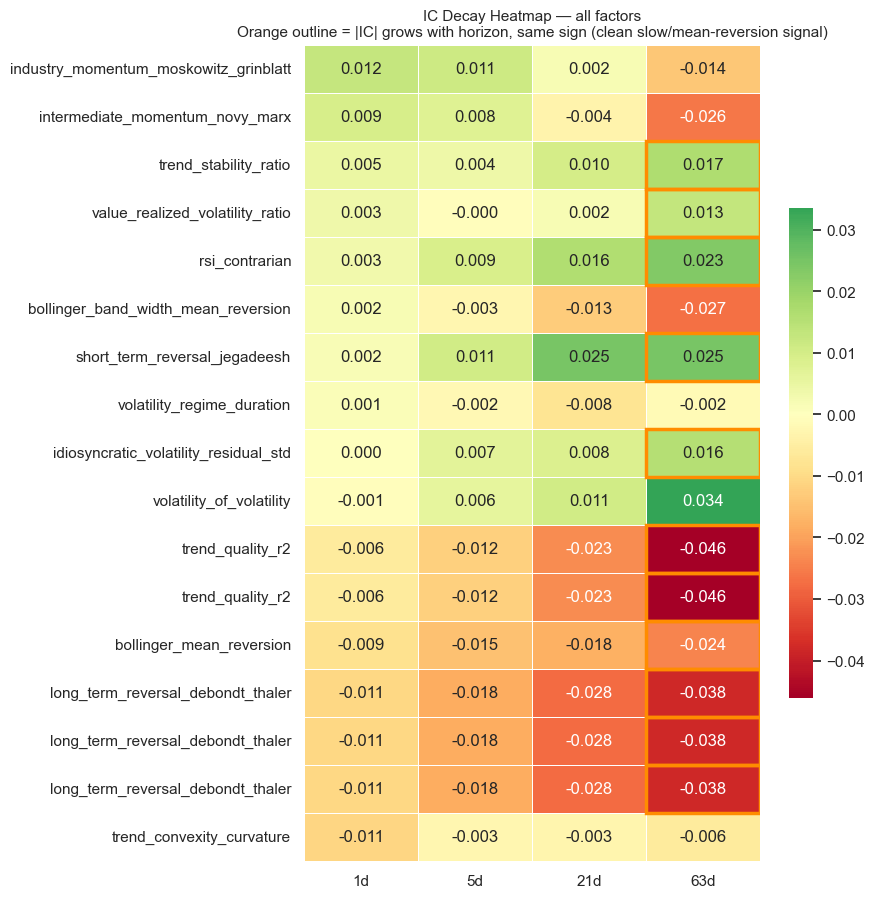

In [11]:
fig = plot_ic_decay_heatmap(KB_PATH)
plt.show()

### Chart 4 — IC vs ICIR Scatter (efficiency frontier)

**Theory:** This scatter maps every factor onto a two-dimensional quality space, separating signal *strength* (IC, x-axis) from signal *consistency* (ICIR, y-axis).

- **Dot size** ∝ daily turnover — larger dots are more expensive to trade
- **Dot colour** = factor domain (momentum, mean-reversion, volatility, quality, value)

**The efficiency frontier** is the upper-right boundary of the scatter cloud.  Factors on this frontier are Pareto-optimal: you cannot increase IC without sacrificing ICIR, or vice versa.

**Quadrant interpretation:**

| Quadrant | IC | ICIR | Interpretation |
|----------|----|----|----------------|
| Top-right | High | High | Best signals — strong and consistent |
| Bottom-right | High | Low | Powerful but unreliable — may be driven by one exceptional year |
| Top-left | Low | High | Consistent but weak — cost drag will likely eliminate it |
| Bottom-left | Low | Low | Noise — discard |

**Turnover interaction:** large dots in the top-right may still fail after costs.  A factor with IC=0.04 and 80% daily turnover can have negative net IC at 10 bps spread.  Always cross-reference with Chart 8 (cost efficiency) and Chart 13 (gross vs net IC) for high-turnover outliers.

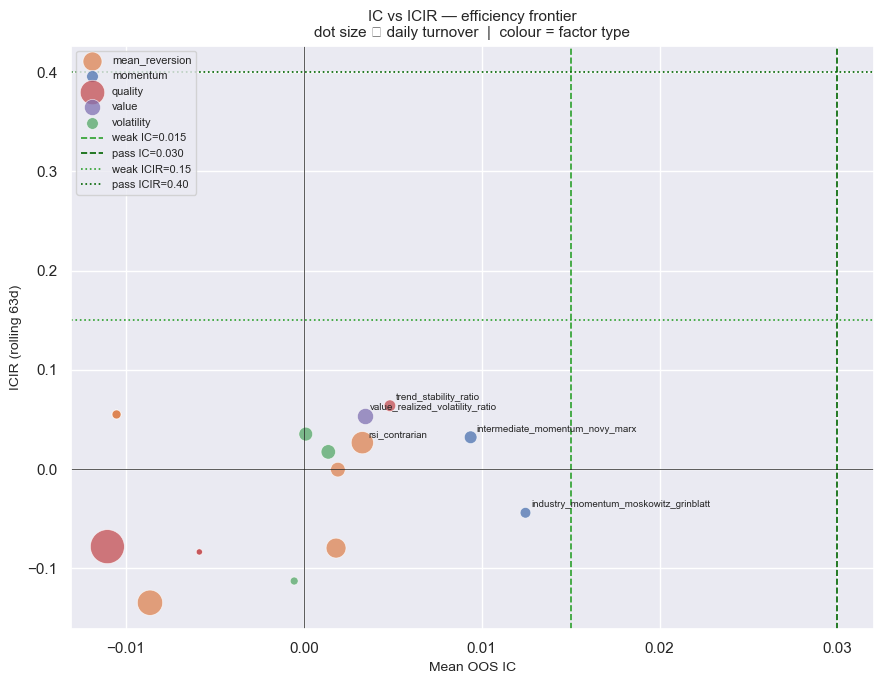

In [12]:
fig = plot_ic_vs_icir(KB_PATH)
plt.show()

### Chart 5 — IC @ 1-day vs IC @ 63-day

**Theory:** This scatter directly separates momentum-type signals from slow-signal candidates using the most informative pair of horizons.

- **x-axis:** IC at h=1 (daily predictive power)
- **y-axis:** IC at h=63 (quarterly predictive power)
- **Diagonal:** factors exactly on the diagonal have equal IC at both horizons (pure persistence with no decay)

**Above the diagonal:** IC@63d > IC@1d — the factor *improves* with holding period.  These are slow signals where a longer hold genuinely adds information.  Regime conditioning (Phase 2) is particularly valuable here because the HSMM can detect whether the market is in a mean-reverting state where these signals flourish.

**Below the diagonal:** IC@1d > IC@63d — standard decay.  Most momentum and microstructure factors fall here; hold them too long and the edge disappears.

**Far top-left quadrant:** IC@1d ≈ 0, IC@63d > 0 — a pure slow signal that daily rebalancing would completely destroy.  These factors should only be evaluated at their natural horizon and will appear as weak FAIL in the standard leaderboard even though they carry real alpha at longer horizons.

**Far bottom-left:** negative IC at both horizons — the factor consistently predicts the *wrong* direction.  Its *negative* is a valid long-short factor.

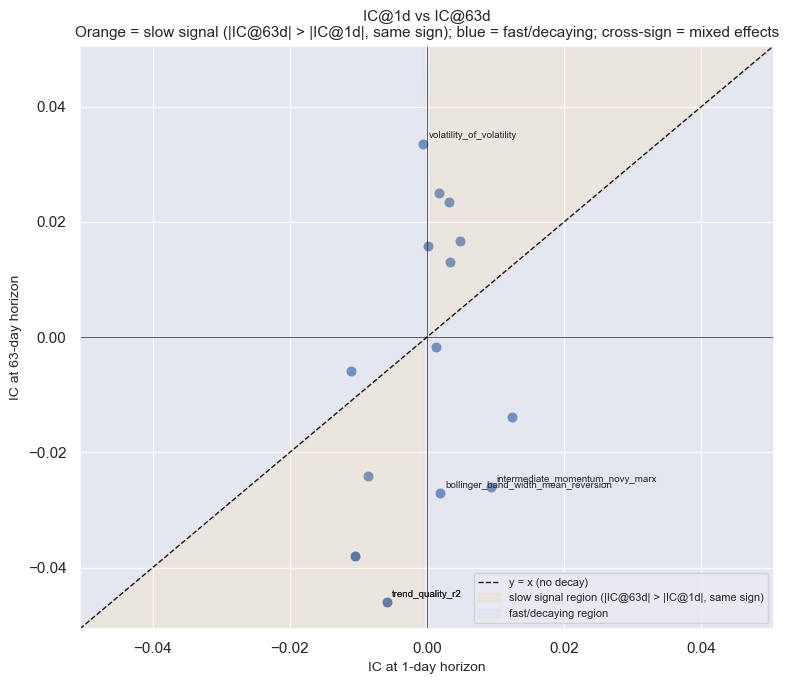

In [13]:
fig = plot_ic1_vs_ic63(KB_PATH)
plt.show()

### Chart 6 — Cumulative IC Across Horizons (top 5)

**Theory:** For each of the top 5 factors, this chart plots cumulative IC summed from h=1 through h=63.  It directly answers: *as you hold the signal for longer, does your total predictive power accumulate or plateau?*

**Rising slope:** total IC keeps growing — the factor's edge accumulates with holding time.  For a momentum signal this usually plateaus by h=5 (most predictive power captured in the first week).  For a quality/value signal the slope may be nearly constant out to h=63, indicating a genuinely patient signal.

**How to use this chart to pick rebalancing frequency:**
- Find the horizon h* where the slope of the cumulative IC curve peaks — this is where marginal IC per extra day of holding is maximised.
- For factors that plateau after h=1, daily rebalancing is optimal; extra holding adds no signal, only turnover drag.
- For factors with slopes that continue rising to h=21 or h=63, monthly rebalancing can cut costs by 20–60× compared to daily rebalancing of a h=1 signal — and the net IC may be substantially higher even if gross IC is lower.

**Interaction with cost model:** the optimal rebalancing frequency balances marginal IC gain against transaction cost.  A rough heuristic: if `IC_h / IC_1 > 1 + cost_bps × h / 1000`, the longer hold is cost-efficient.

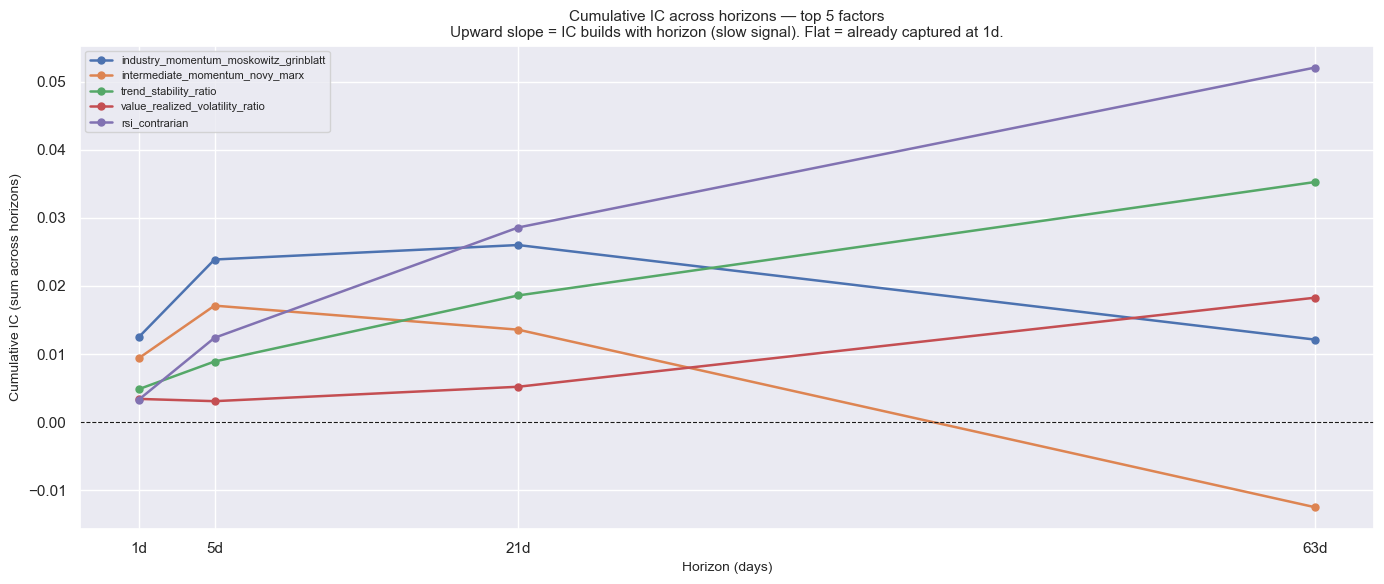

In [14]:
fig = plot_cumulative_ic(KB_PATH, top_n=5)
plt.show()

### Chart 7 — Standard ICIR vs Slow ICIR (21d / 63d)

**Theory:** For slow-decay factors (IC peaking at h≥21d), the standard ICIR is measured at the *wrong frequency* and dramatically overstates statistical significance.

**The inflation problem:** consecutive 63-day IC observations share 62 days of forward returns — they are almost perfectly autocorrelated, not independent.  A factor with true independent-window ICIR of 0.3 can appear to have standard ICIR of 2.0.  This inflates t-statistics by up to √63 ≈ 8×, producing false positives in any multiple-testing framework.

**Correct slow-signal metrics:**
- `slow_icir_21` — ICIR computed on non-overlapping 21-day windows (~84 windows over 7 years)
- `slow_icir_63` — ICIR computed on non-overlapping 63-day windows (~28 windows over 7 years)

**For BHY significance testing**, slow signals must use: `t = slow_icir_63 × √(N / 63)` where N is the number of OOS trading days.  Using the standard formula produces false positives.

**What the chart shows:** three bars per factor — standard ICIR (blue), slow_icir_21 (orange), slow_icir_63 (green).  A large drop from blue to green reveals a slow signal where the standard metric was misleading.  Any factor with a high blue bar but low green bar is *not* BHY-significant via the honest formula.

> **Note:** `slow_icir_21` and `slow_icir_63` only exist for results from after the harness upgrade (2026-04-13). Earlier results show 0.

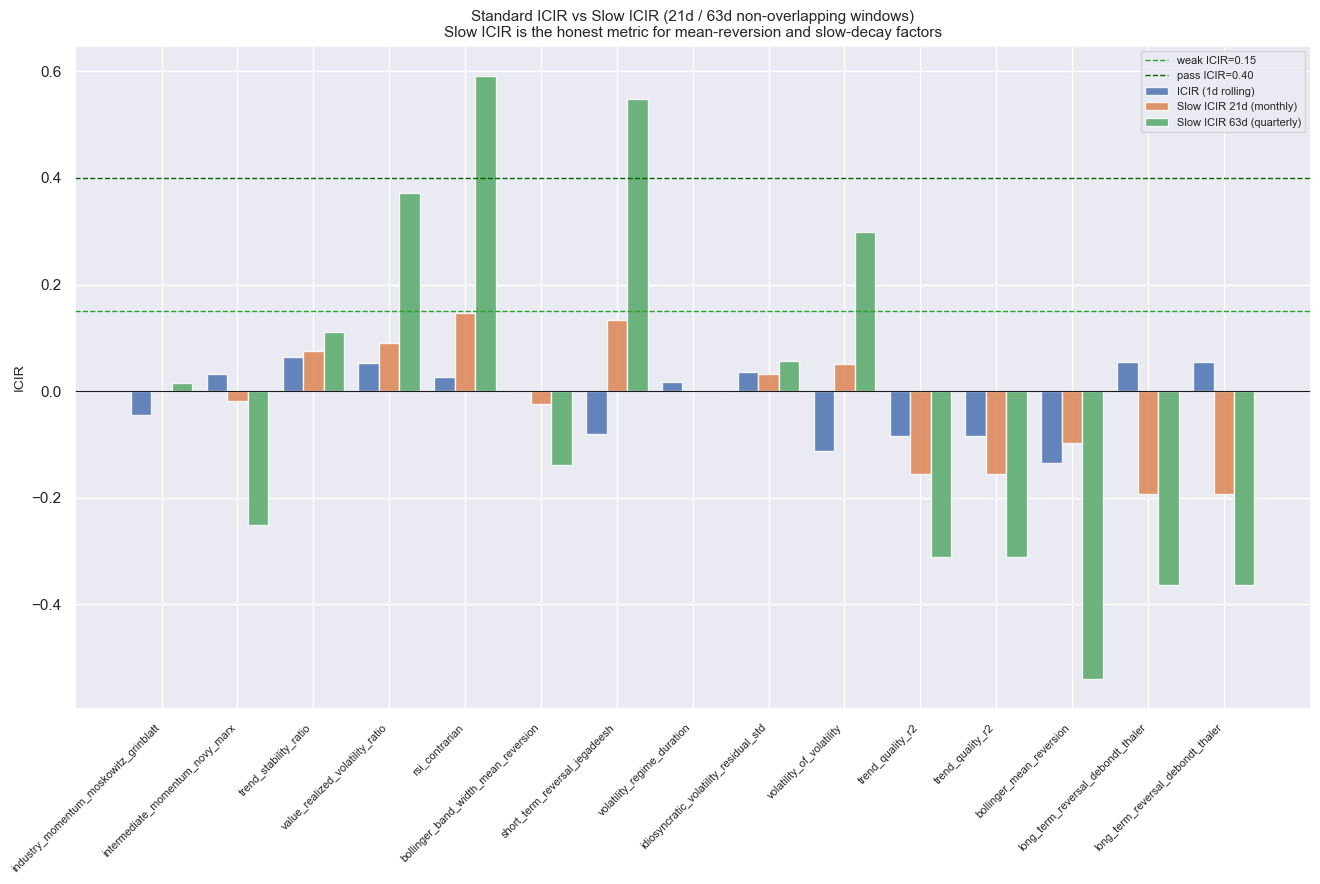

In [15]:
fig = plot_slow_icir_comparison(KB_PATH, top_n=15)
plt.show()

### Chart 8 — Turnover vs IC (cost efficiency scatter)

**Theory:** This scatter directly maps the tradeoff between signal strength and the cost of exploiting it.

- **x-axis:** daily one-way turnover (fraction of portfolio replaced per day; 0.10 = 10%/day)
- **y-axis:** mean IC (net, after costs)
- **Break-even line (red):** minimum IC needed to cover transaction costs at that turnover level, from the cost model (10 bps spread, 10% ADV impact)

**Interpretation:**
- Factors **above** the break-even line have positive net IC — these are viable trading signals after realistic execution costs.
- Factors **below** the line generate gross IC but lose it all (or more) to transaction costs — they are statistical artefacts, not deployable alpha.
- The ideal factor sits **top-left**: high IC with low turnover.

**Cost efficiency ratio** = net_ic / gross_ic.  The Phase 2.5 Gate 3 criterion requires ≥ 90% efficiency.  A factor at 99% efficiency is effectively cost-free; a factor at 50% efficiency loses half its signal to friction.

**Important note:** the cost model uses conservative but realistic assumptions for large-cap equities.  Actual costs at large AUM (>$50M) will be higher due to market impact scaling.  Use `AGGRESSIVE_COST_PARAMS` in `costs.py` to stress-test high-turnover factors.

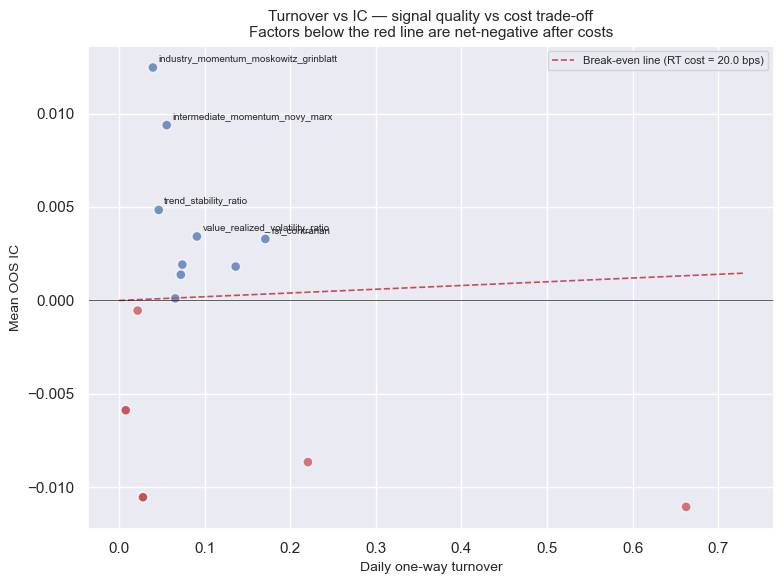

In [16]:
fig = plot_turnover_scatter(KB_PATH)
plt.show()

### Chart 9 — Factor Correlation Heatmap

**Theory:** Correlation between factor signals measures how much *independent* information each factor contributes to a combined portfolio.  A library where all pairwise correlations are below 0.3 provides dramatically better diversification than one where most factors have ρ > 0.8.

- **Spearman rank correlation** is used (not Pearson) for robustness to outliers and nonlinear relationships.
- Correlation is computed on the raw OOS signals (daily cross-sectional ranks), not on IC time series — it measures whether two factors are pointing at the *same stocks*, not just whether their daily IC happened to move together.

**How to read the heatmap:**
- **Deep red (ρ ≈ 1.0):** near-duplicate signals — two implementations of the same economic mechanism.  Keep only the one with the better net IC; adding the other provides almost no diversification.
- **Light colour (|ρ| < 0.3):** genuinely independent signals — ideal candidates for blending.  The combined signal's ICIR is higher than either component alone.
- **Negative ρ:** anti-correlated — blending them creates a natural hedge; the combined signal has lower drawdown than either alone.  Only combine if both are individually positive-IC.

**Ensemble construction:** the pipeline's auto-ensemble (`run_ensemble_check()`) penalises near-duplicate factors using the correlation matrix, so the ensemble weight for factor i is proportional to `IC_i / (1 + mean|ρ_i|)`.

> **Note:** this chart requires `run_correlation_analysis()` to have run first.  This happens automatically every 5 iterations when using `./run_pipeline.sh`.

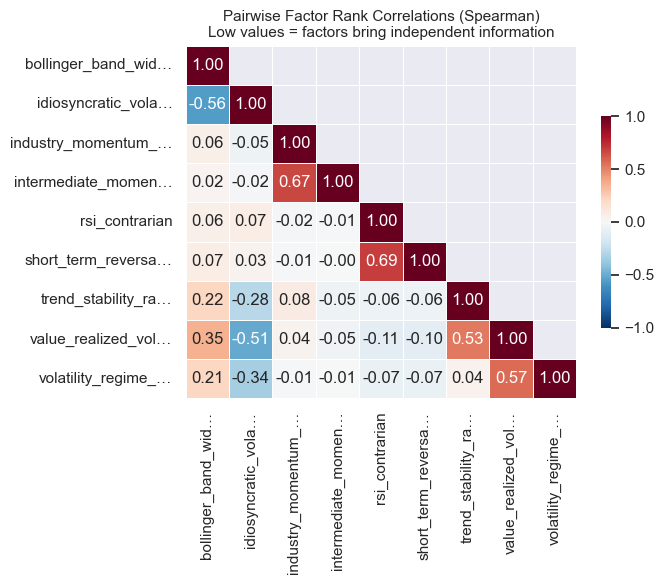

In [17]:
fig = plot_correlation_heatmap(KB_PATH)
plt.show()

### Chart 10 — IC Sharpe Distribution

**Theory:** The distribution of IC Sharpe ratios across *all* tested factors reveals the baseline quality of randomly generated factors on this universe and domain mix.

- **Mean near zero:** if the pipeline generated pure noise, the distribution would centre at zero.  A positive mean indicates the synthesis agent is biased toward factor families with genuine economic content.
- **Right tail:** the strongest factors stand out here.  A well-functioning pipeline should show a small cluster of outliers at Sharpe > 1.5 clearly separated from the noise bulk.
- **Width of distribution:** a very wide distribution indicates high variance in factor quality.  A tight distribution near zero means most proposed factors are noise with occasional lucky outliers.

**Interpreting the distribution for pipeline quality:**
- Symmetric around zero → the synthesis agent is generating ideas with no consistent direction of quality; consider changing the domain or refining the prompt.
- Right-skewed → some factor families are genuinely predictive; the tail factors are worth deeper investigation.
- Many Sharpe > 3 outliers → check for look-ahead bias or data-snooping artefacts.  Legitimate OOS signal on 7 years of daily data rarely exceeds Sharpe 3 legitimately.

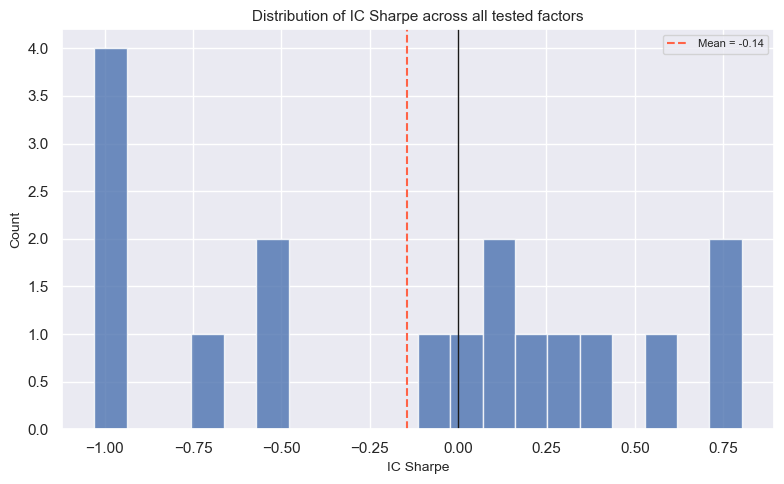

In [18]:
fig = plot_sharpe_histogram(KB_PATH)
plt.show()

### Chart 11 — Domain Breakdown

**Theory:** This chart answers: *which factor domains are most fertile for alpha on the S&P 500 universe?*  Each bar shows factors tested per domain (total) and the fraction that achieved positive IC (coloured fill).

**Domains and their economic rationale:**

| Domain | Core mechanism | Typical signal horizon |
|--------|---------------|----------------------|
| `momentum` | Underreaction to information / trend persistence | 1–63 days |
| `mean_reversion` | Overreaction / temporary price divergence from fair value | 21–126 days |
| `volatility` | Risk-adjusted pricing, variance risk premium | 1–21 days |
| `quality` | Earnings quality, balance sheet strength, capital efficiency | 63–252 days |
| `value` | Fundamental mispricing relative to accounting metrics | 63–252 days |

**Research allocation guide:**
- Domains with a **high positive-IC rate but few tests** are under-explored — worth running more iterations here.
- Domains with **many tests but low positive-IC rate** may be exhausted on this universe or structurally difficult — consider reducing allocation.
- The synthesis agent reads this breakdown before proposing new hypotheses and will emphasise domains where past seeds showed signal.

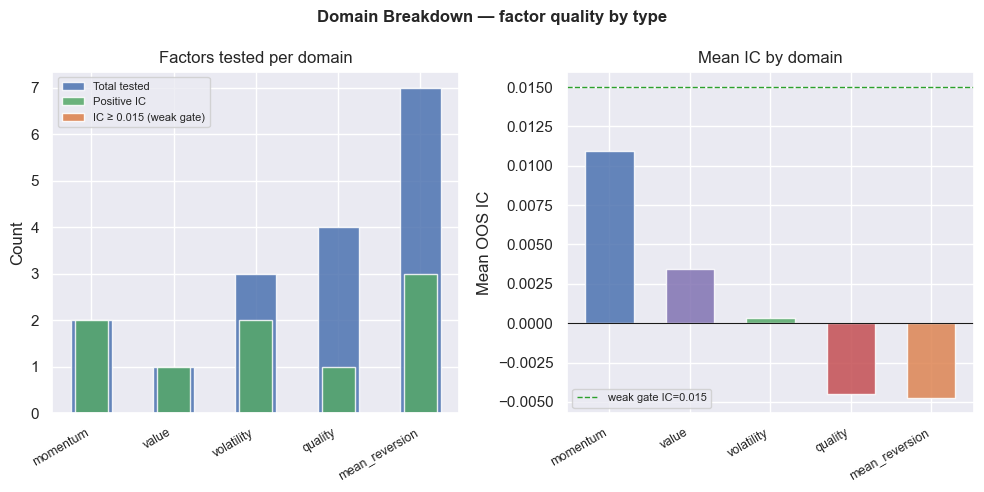

In [19]:
fig = plot_domain_breakdown(KB_PATH)
plt.show()

### Chart 12 — Hypothesis Outcomes Over Time

**Theory:** This time-series tracks the running count of hypothesis outcomes (pass, weak, fail, error) as the pipeline progresses.  It reveals whether the pipeline is learning from its own history.

**What the trajectory tells you:**

- **Declining fail rate over time:** the synthesis agent is successfully using past KB results as context and avoiding factor families it has already explored.  This is the intended behaviour — the agentic loop is self-improving.
- **Constant or rising fail rate:** the agent is not effectively learning from history.  Possible causes: KB context not being read, domain is genuinely exhausted, or the LLM is ignoring the seed examples.
- **Sudden spike in errors:** a code generation failure (e.g., LLM using disallowed library calls, factor computation timeout).  Check `pipeline/agents/implementation.py` for recent error messages.

**Practical implications:**
- The pipeline typically requires 20–40 iterations per domain before BHY-significant factors emerge.
- Running fewer than 10 factors per domain gives the BHY correction nothing meaningful to work with (m too small for reliable FDR control).
- The practical target is **80–120 total factors across 4–5 domains** before applying the full BHY correction.  More is better up to diminishing returns around m=200.

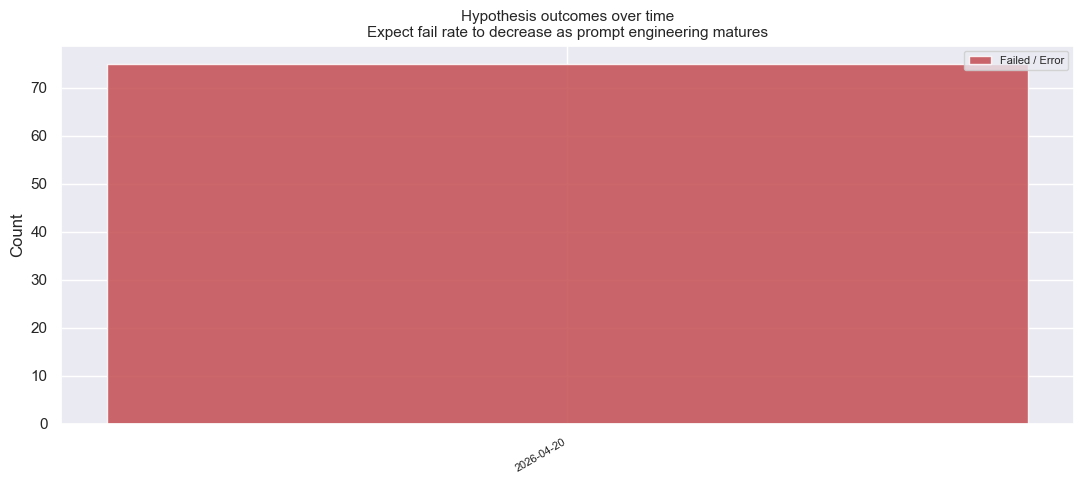

In [20]:
fig = plot_error_rate(KB_PATH)
plt.show()

### Chart 13 — Gross IC vs Net IC (cost drag per factor)

**Theory:** This bar chart compares gross IC (before costs) to net IC (after bid-ask spread, market impact, and borrow) for the top factors.  The gap is the cost drag — alpha that exists statistically but cannot be captured at standard execution costs.

**Cost model components (DEFAULT_COST_PARAMS):**

| Component | Assumption | Who pays it |
|-----------|-----------|-------------|
| Bid-ask spread | 10 bps round-trip | Every trade |
| Market impact | Almgren et al. model, 10% ADV | All trades, scaled to size |
| Short borrow | 50 bps/year annualised | Short book only |

**Reading the chart:**
- **Small gap** between gross and net bars = cost-efficient signal.  Most of the alpha survives execution.  Good candidate for real-world deployment.
- **Large gap** = cost-intensive factor.  The alpha is statistically real but most of it is consumed by the bid-ask spread.  Viable only with superior execution (limit orders, crossing internal flow, dark pools).
- **Positive gross IC, negative net IC** = a paper signal.  It exists in the data but cannot be monetised at standard execution costs.  Do not promote to Phase 2.

**Gate 3 criterion (Phase 2.5):** cost efficiency = net_ic / gross_ic ≥ 90%.  A factor at 99% efficiency is essentially cost-free; a factor at 50% efficiency loses half its signal to friction and is structurally unattractive regardless of gross IC magnitude.

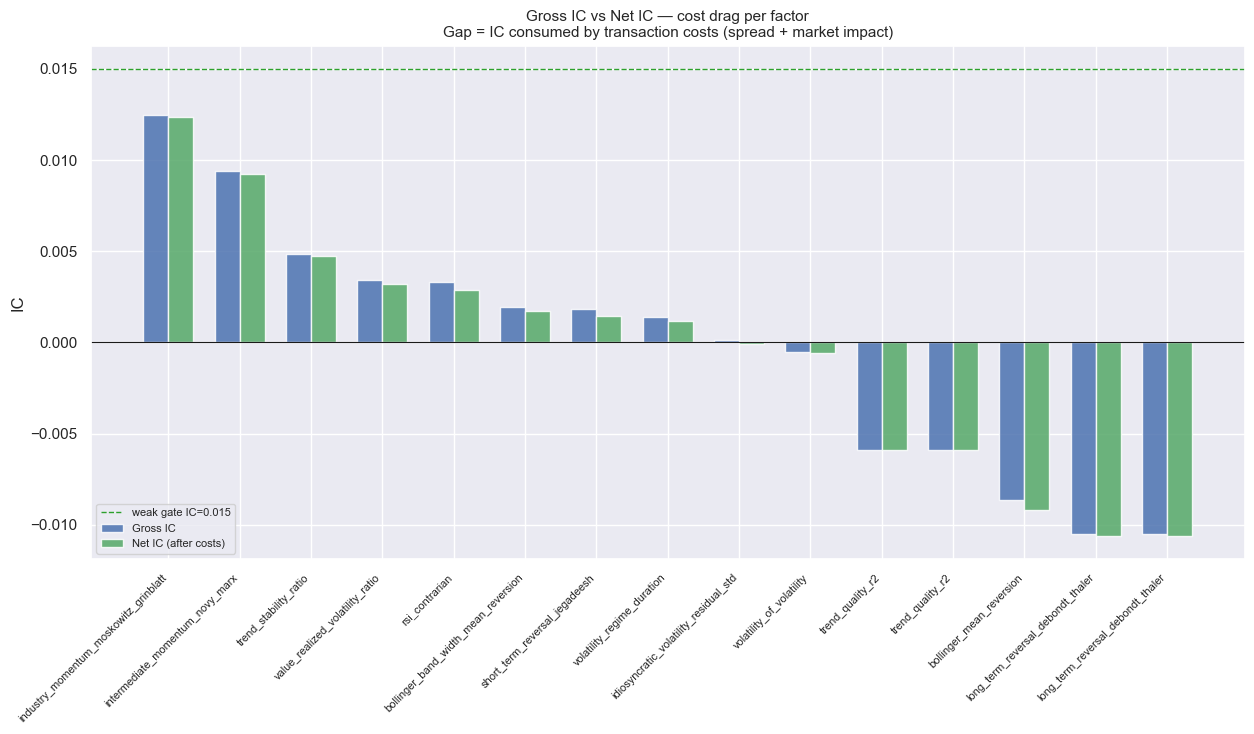

In [21]:
fig = plot_net_vs_gross_ic(KB_PATH, top_n=15)
plt.show()

### Chart 14 — IC by Calendar Period (Temporal Stability)

This is a **stability diagnostic**, not a significance test.

It answers: *"Was the factor's IC consistent across all market environments, or did it only work in one era?"*

A factor with IC ≈ 0.015 in every 2-year block (2018–20, 2020–22, 2022–24) is far more trustworthy than one with IC = 0.06 in a single period and IC ≈ 0 elsewhere — even if the full-period mean is the same.

- **Error bars** = 95% confidence intervals (±1.96 × std / √n_days)
- **Bar colour** = blue if positive, red if negative
- **ICIR annotation** = within-period IC Sharpe (shown above each bar)

> Note: splitting 1760 daily ICs into 5 blocks of 352 each does NOT improve the main t-statistic. Use the full-period t-stat from `multiple_testing.py` for significance. Use this chart for **stability only**.

Change `impl_id=` to inspect any factor from the knowledge base.

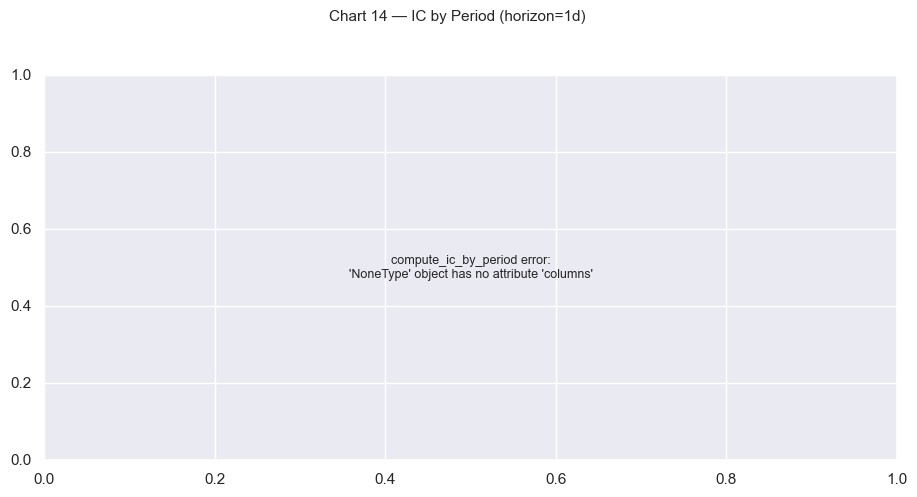

In [22]:
# Chart 14 — IC by calendar period (temporal stability)
# impl_id=1  → 12-1 momentum (fast signal, use HORIZON=1)
# impl_id=53 → price_level_autocorrelation (slow signal, set HORIZON=63 in setup cell)
#
# Change impl_id to inspect any factor.
# The HORIZON variable (set in the setup cell) selects the holding period.
# Slow signals (IC peaks at h=63) must be evaluated at HORIZON=63 —
# evaluating them at HORIZON=1 dramatically understates their predictive power.

PRICES_PATH = os.path.join(repo_root, 'data', 'processed', 'sp500_close.parquet')

fig = plot_ic_by_period(
    KB_PATH,
    impl_id=1,                  # change to any impl_id in your KB
    prices_path=PRICES_PATH,
    oos_start='2018-01-01',
    period_years=2.0,
    horizon=HORIZON,            # ← uses the HORIZON variable from setup cell
)
fig.suptitle(f'Chart 14 — IC by Period (horizon={HORIZON}d)', fontsize=11, y=1.01)
plt.show()

# ── Quick slow-signal example (uncomment to run) ──────────────────────────
# fig2 = plot_ic_by_period(KB_PATH, impl_id=53, prices_path=PRICES_PATH, horizon=63)
# fig2.suptitle('Chart 14 — IC by Period (impl_53, horizon=63d)', fontsize=11, y=1.01)
# plt.show()

### Chart 15 — Multiple Testing Significance

**Why multiple testing correction is necessary:**

We have tested ~84 factors on the **same dataset**.  By chance alone, ~4 will appear significant
at p < 0.05 (84 × 0.05 = 4.2 false discoveries).  Without correction, we might promote noise
as alpha.

**BHY (Benjamini-Hochberg-Yekutieli) correction:**
- Controls the *False Discovery Rate* (FDR) — the expected fraction of "significant" results
  that are actually false
- Designed for *dependent* tests — appropriate here because factor signals are correlated
- Threshold at α=0.05 FDR: approximately t ≥ 4.0 with 84 factors tested

**Reading the chart:**
- Each bar is a factor's t-statistic (= IC Sharpe × √(n_OOS_days / 252))
- Blue dashed line = BHY threshold (~4.0) — bars crossing this are BHY-significant
- Orange line = HLZ threshold (Harvey, Liu & Zhu 2016) — more conservative
- Red dashed line = Bonferroni threshold — most conservative (controls family-wise error rate)

**Phase 2 graduation gate:** Only BHY-significant factors proceed to Phase 2 regime analysis.


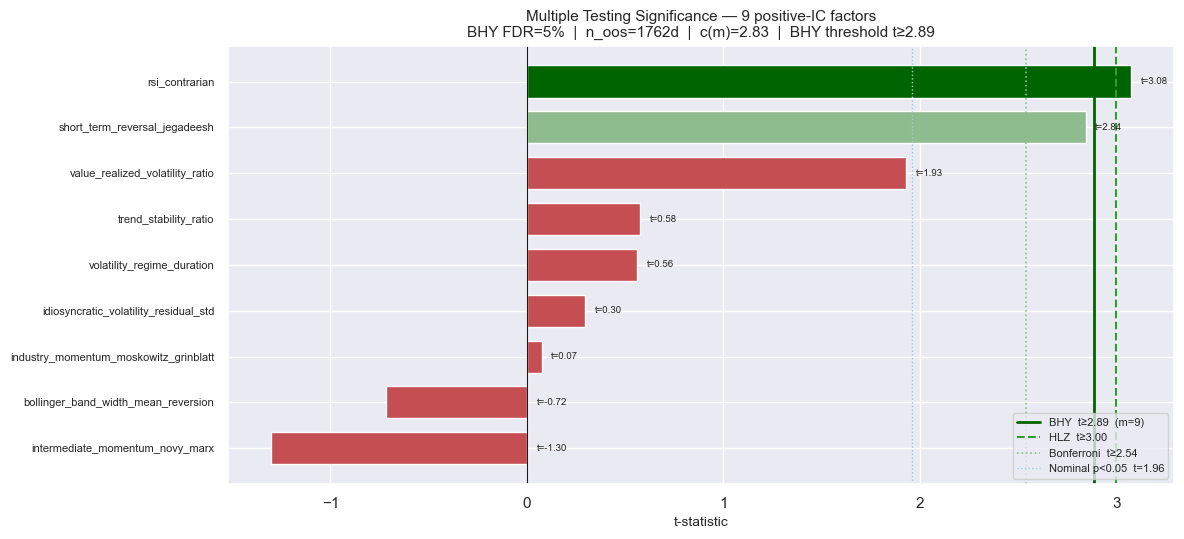

In [23]:
fig = plot_multiple_testing(KB_PATH, alpha=0.05, n_oos_days=1762)
plt.show()

### Multiple Testing Table — Full Correction Summary

Tabular output from `correct_ic_pvalues()`. Columns: factor name, IC, t-stat, raw p-value, BHY-significant, HLZ-significant.

In [24]:
from qframe.factor_harness.multiple_testing import correct_ic_pvalues, print_correction_summary

all_results = kb.get_all_results()
corrected = correct_ic_pvalues(all_results, alpha=0.05, n_oos_days=1762)
print_correction_summary(corrected)
corrected[['factor_name', 'ic', 'icir', 't_stat', 'p_raw', 'bhy_significant', 'hlz_sig']].head(20)


Multiple Testing Correction  (m=9 positive-IC factors, α=0.05)
  BHY (FDR control):       t ≥ 2.89  required for significance
  Harvey-Liu-Zhu (2016):   t ≥ 3.00  (= √(2·ln(9)))
  Bonferroni (FWER):       t ≥ 2.54  (most conservative)

                          factor_name     ic  t_stat  p_raw  bhy_significant  hlz_sig
industry_momentum_moskowitz_grinblatt 0.0125  0.0749 0.4702            False    False
      intermediate_momentum_novy_marx 0.0094  1.9340 0.0266            False    False
                trend_stability_ratio 0.0048  0.5759 0.2824            False    False
      value_realized_volatility_ratio 0.0034  1.9296 0.0269            False    False
                       rsi_contrarian 0.0033  3.0751 0.0011             True     True
  bollinger_band_width_mean_reversion 0.0019  0.4020 0.3439            False    False
        short_term_reversal_jegadeesh 0.0018  2.8437 0.0023             True    False
           volatility_regime_duration 0.0014  0.5615 0.2872            Fals

,factor_name,ic,icir,t_stat,p_raw,bhy_significant,hlz_sig
0,industry_momentum_moskowitz_grinblatt,0.012461,-0.043885,0.074850,0.470171,False,False
1,intermediate_momentum_novy_marx,0.009378,0.032143,1.933968,0.026639,False,False
2,trend_stability_ratio,0.004842,0.063944,0.575865,0.282390,False,False
3,value_realized_volatility_ratio,0.003423,0.053735,1.929608,0.026908,False,False
4,rsi_contrarian,0.003290,0.026708,3.075064,0.001068,True,True
5,bollinger_band_width_mean_reversion,0.001916,-0.000428,0.402029,0.343856,False,False
6,short_term_reversal_jegadeesh,0.001813,-0.079467,2.843744,0.002255,True,False
7,volatility_regime_duration,0.001377,0.017422,0.561542,0.287250,False,False
8,idiosyncratic_volatility_residual_std,0.000111,0.035367,0.298437,0.382702,False,False
